<a href="https://colab.research.google.com/github/tomasbelak24/deeplearning-vision/blob/main/hw1/dropout_augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Optimization (4pt)

Test training with Adam, SGD or RMSProp optimizers. Run at least 4 different configurations (different steps, different alpha, beta, etc). For this task, it is advisable to use the graphs in the pdf.

Choose one method and additionally test three other minibatch sizes for it.

In [1]:
!mkdir -p baseline
# I might make the repo private in the future so the files from /baseline directory from the zip file might have to be used
!wget -O baseline/baseline_model.pth https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
!wget -O baseline/baseline_results.json https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json


--2025-11-09 16:22:22--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381333 (372K) [application/octet-stream]
Saving to: ‘baseline/baseline_model.pth’

baseline/baseline_m 100%[===================>] 372.40K  --.-KB/s    in 0.02s   

2025-11-09 16:22:23 (18.3 MB/s) - ‘baseline/baseline_model.pth’ saved [381333/381333]

--2025-11-09 16:22:23--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443.

In [2]:
import json

with open('baseline/baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

baseline_train_losses = baseline_results['train_losses']
baseline_val_losses = baseline_results['val_losses']
baseline_val_accs = baseline_results['val_accuracies']

print("Baseline results loaded successfully.")

Baseline results loaded successfully.


In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
from matplotlib import pyplot as plt

100%|██████████| 170M/170M [00:03<00:00, 43.7MB/s]


torch.Size([1, 3, 32, 32])


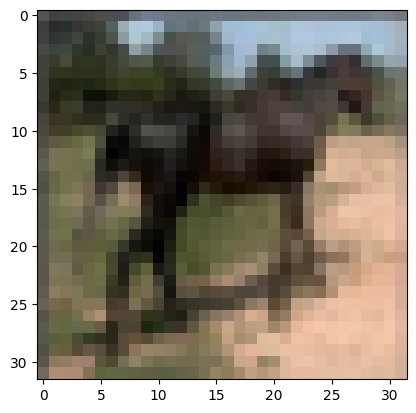

tensor([7])
horse
torch.Size([1, 3, 32, 32])


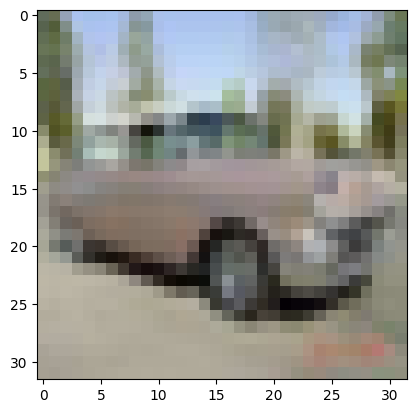

tensor([1])
car
torch.Size([1, 3, 32, 32])


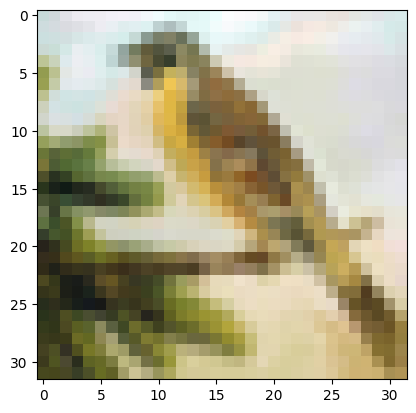

tensor([2])
bird
torch.Size([1, 3, 32, 32])


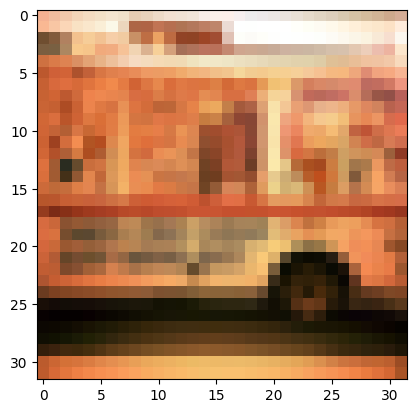

tensor([9])
truck
torch.Size([1, 3, 32, 32])


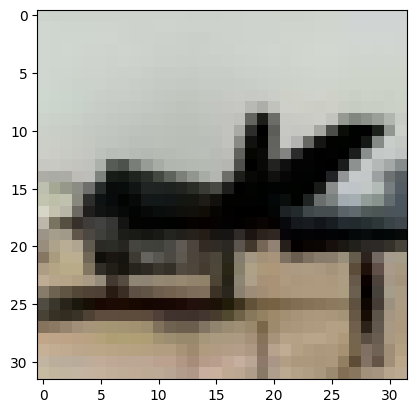

tensor([0])
plane
torch.Size([1, 3, 32, 32])


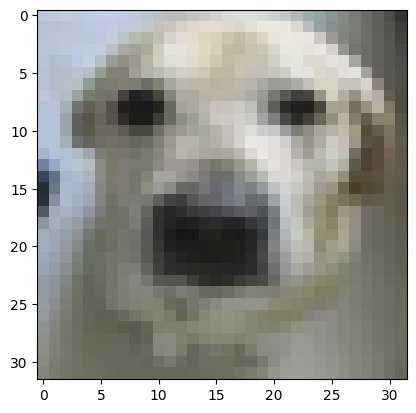

tensor([5])
dog
torch.Size([1, 3, 32, 32])


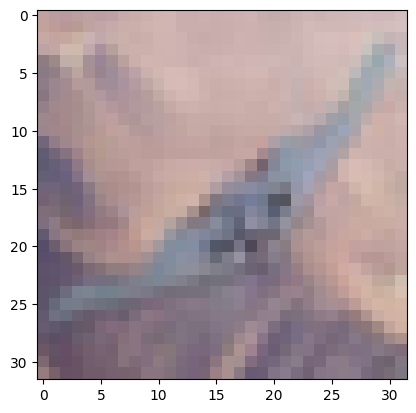

tensor([0])
plane
torch.Size([1, 3, 32, 32])


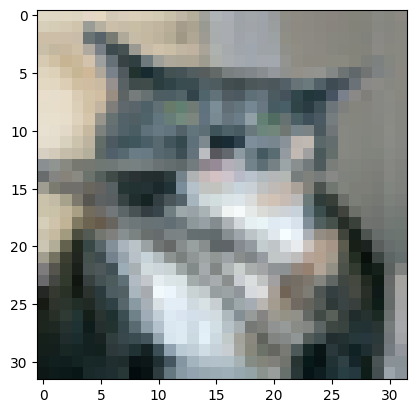

tensor([3])
cat
torch.Size([1, 3, 32, 32])


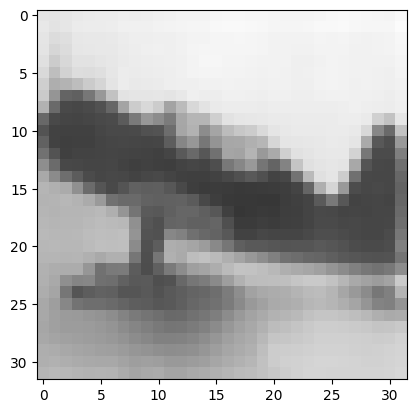

tensor([0])
plane
torch.Size([1, 3, 32, 32])


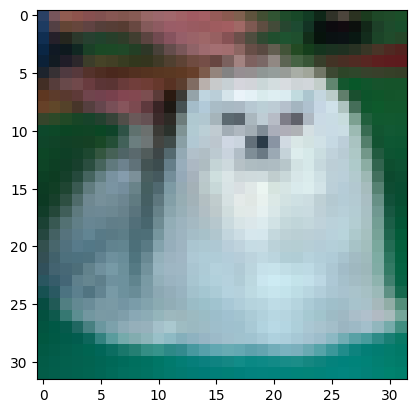

tensor([5])
dog
torch.Size([1, 3, 32, 32])


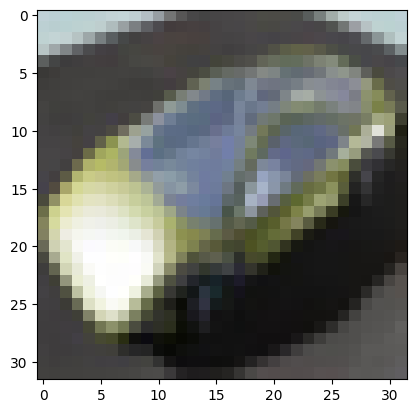

tensor([1])
car


In [4]:
# @title Loading CIFAR10 dataset

#reused code from the 5th lab

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# for reproducibility
trainset, valset = torch.utils.data.random_split(dataset, [45000, 5000], generator=torch.Generator().manual_seed(42))

previewloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

for i, sample in enumerate(previewloader):
  if i > 10:
    break
  x, y = sample
  print(x.shape)
  img = np.moveaxis(x.numpy()[0], 0, -1)
  plt.imshow(img)
  plt.show()
  print(y)
  print(classes[y.item()])

In [5]:
from torch.nn import ReLU, Softmax, Sequential, Linear, Conv2d, MaxPool2d, Flatten, AdaptiveAvgPool2d

def build_model_task3(num_classes=10):
  model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),
        Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),
        Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, num_classes)
    )

  model_inference = Sequential(model, Softmax(dim=1))
  return model, model_inference

model, model_inference = build_model_task3()

out = model_inference(torch.from_numpy(np.zeros([1, 3, 32, 32], dtype=np.float32)))
print(out.size())
print(out)
print(classes[out.argmax().item()])

torch.Size([1, 10])
tensor([[0.1034, 0.1013, 0.0990, 0.1013, 0.0894, 0.1000, 0.1012, 0.1038, 0.1033,
         0.0974]], grad_fn=<SoftmaxBackward0>)
horse


In [6]:
def one_epoch(model, loss, optimizer, dataloader_train, dataloader_val, verbose=True):
  train_losses = []
  val_losses = []

  model.train()
  for i, batch in enumerate(dataloader_train):
    x, y = batch[0].to(device), batch[1].to(device)
    optimizer.zero_grad()

    out = model(x)
    loss = ce_loss(out, y)
    loss.backward()
    train_losses.append(loss.item())
    optimizer.step()
    if i % 100 == 0 and verbose:
      print("Training loss at step {}: {}".format(i, loss.item()))

  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for i, batch in enumerate(dataloader_val):
      x, y = batch[0].to(device), batch[1].to(device)

      out = model(x)
      loss = ce_loss(out, y)
      acc = torch.sum(torch.argmax(out, dim=-1) == y)
      correct += acc.item()
      total += len(batch[1])
      val_losses.append(loss.item())

  val_acc = correct / total

  return np.mean(train_losses), np.mean(val_losses), val_acc

Using device:  cuda:0
Trying optimizer: adam_lr0.01_beta0.85
[{'lr': 0.01, 'betas': (0.85, 0.99), 'eps': 1e-08, 'weight_decay': 0, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': False, 'params': [0, 1, 2, 3, 4, 5, 6, 7]}]
Val loss at epoch 0: 1.5375067724543772
Val acc at epoch 0: 0.4284
Val loss at epoch 1: 1.3741277904267524
Val acc at epoch 1: 0.4912
Val loss at epoch 2: 1.3403504327603966
Val acc at epoch 2: 0.5322
Val loss at epoch 3: 1.2781039529545293
Val acc at epoch 3: 0.5442
Val loss at epoch 4: 1.2636291699804318
Val acc at epoch 4: 0.5526
Val loss at epoch 5: 1.216859735121393
Val acc at epoch 5: 0.5666
Val loss at epoch 6: 1.22230005150388
Val acc at epoch 6: 0.5704
Val loss at epoch 7: 1.2111368502021596
Val acc at epoch 7: 0.5738
Val loss at epoch 8: 1.2002658221372373
Val acc at epoch 8: 0.5754
Val loss at epoch 9: 1.2010312896625253
Val acc at epoch 9: 0.5802
Val loss at epoch

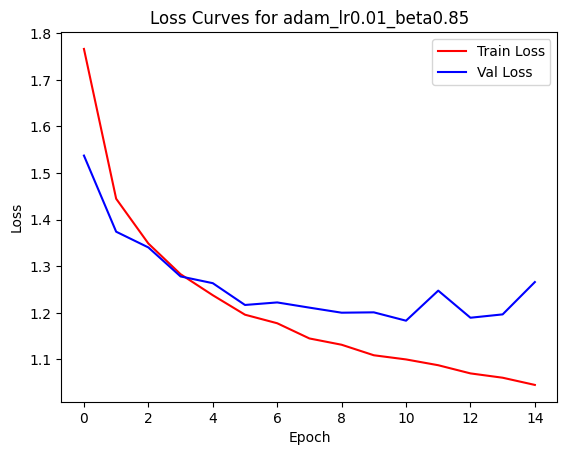

Trying optimizer: adam_lr0.0001
[{'lr': 0.0001, 'betas': (0.9, 0.999), 'eps': 1e-08, 'weight_decay': 0, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': False, 'params': [0, 1, 2, 3, 4, 5, 6, 7]}]
Val loss at epoch 0: 1.8861071486381968
Val acc at epoch 0: 0.3062
Val loss at epoch 1: 1.776727289910529
Val acc at epoch 1: 0.3532
Val loss at epoch 2: 1.706131837170595
Val acc at epoch 2: 0.3808
Val loss at epoch 3: 1.6571501652905896
Val acc at epoch 3: 0.3958
Val loss at epoch 4: 1.6121856164021098
Val acc at epoch 4: 0.4278
Val loss at epoch 5: 1.585604205253018
Val acc at epoch 5: 0.43
Val loss at epoch 6: 1.568301791598083
Val acc at epoch 6: 0.445
Val loss at epoch 7: 1.5402771128211052
Val acc at epoch 7: 0.4524
Val loss at epoch 8: 1.515007865656713
Val acc at epoch 8: 0.4572
Val loss at epoch 9: 1.4955116320567525
Val acc at epoch 9: 0.465
Val loss at epoch 10: 1.4667171118365732
Val acc a

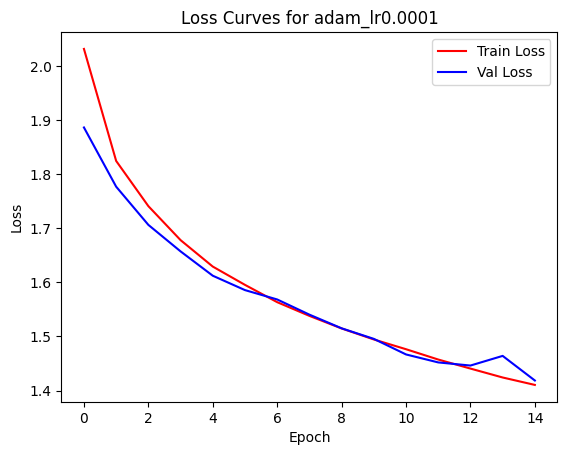

Trying optimizer: SGD_lr0.01
[{'lr': 0.01, 'momentum': 0.9, 'dampening': 0, 'weight_decay': 0, 'nesterov': False, 'maximize': False, 'foreach': None, 'differentiable': False, 'fused': None, 'params': [0, 1, 2, 3, 4, 5, 6, 7]}]
Val loss at epoch 0: 1.7085610840730607
Val acc at epoch 0: 0.3578
Val loss at epoch 1: 1.4445618778277354
Val acc at epoch 1: 0.5016
Val loss at epoch 2: 1.2848620486866897
Val acc at epoch 2: 0.5462
Val loss at epoch 3: 1.2076674301153536
Val acc at epoch 3: 0.5612
Val loss at epoch 4: 1.128081614804116
Val acc at epoch 4: 0.6092
Val loss at epoch 5: 1.100685818939452
Val acc at epoch 5: 0.6086
Val loss at epoch 6: 1.0272623285366471
Val acc at epoch 6: 0.636
Val loss at epoch 7: 0.933123494978923
Val acc at epoch 7: 0.6718
Val loss at epoch 8: 0.934164922138688
Val acc at epoch 8: 0.6692
Val loss at epoch 9: 0.9250266929720617
Val acc at epoch 9: 0.6712
Val loss at epoch 10: 0.9202517726618773
Val acc at epoch 10: 0.6828
Val loss at epoch 11: 0.922332076320223

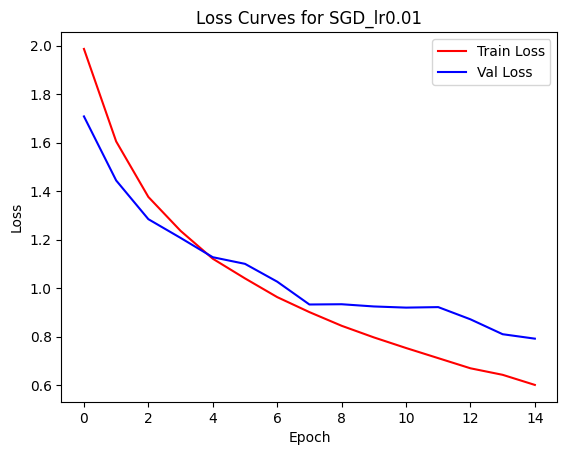

Trying optimizer: SGD_lr0.1
[{'lr': 0.1, 'momentum': 0.9, 'dampening': 0, 'weight_decay': 0, 'nesterov': False, 'maximize': False, 'foreach': None, 'differentiable': False, 'fused': None, 'params': [0, 1, 2, 3, 4, 5, 6, 7]}]
Val loss at epoch 0: 2.3055831960811735
Val acc at epoch 0: 0.1008
Val loss at epoch 1: 2.314809017120653
Val acc at epoch 1: 0.0942
Val loss at epoch 2: 2.312780132718906
Val acc at epoch 2: 0.0942
Val loss at epoch 3: 2.30822369854921
Val acc at epoch 3: 0.1008
Val loss at epoch 4: 2.317832069032511
Val acc at epoch 4: 0.0942
Val loss at epoch 5: 2.3096393703655074
Val acc at epoch 5: 0.0942
Val loss at epoch 6: 2.3198200471841606
Val acc at epoch 6: 0.0942
Val loss at epoch 7: 2.3100858448417325
Val acc at epoch 7: 0.1002
Val loss at epoch 8: 2.3171185277829505
Val acc at epoch 8: 0.0942
Val loss at epoch 9: 2.304014011553139
Val acc at epoch 9: 0.0942
Val loss at epoch 10: 2.3073408406251557
Val acc at epoch 10: 0.1024
Val loss at epoch 11: 2.3185023350320804
V

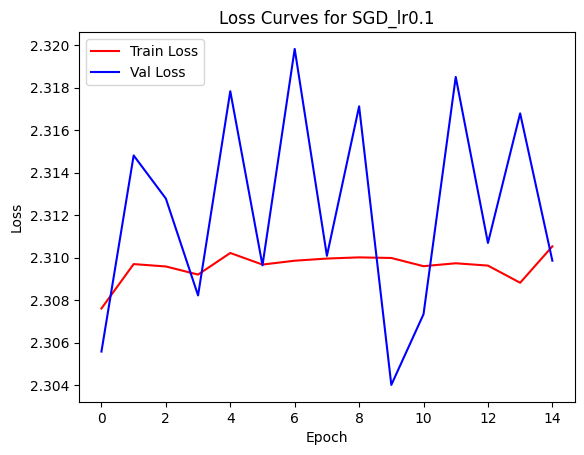

Trying optimizer: RMSprop
[{'lr': 0.01, 'momentum': 0, 'alpha': 0.99, 'eps': 1e-08, 'centered': False, 'weight_decay': 0, 'capturable': False, 'foreach': None, 'maximize': False, 'differentiable': False, 'params': [0, 1, 2, 3, 4, 5, 6, 7]}]
Val loss at epoch 0: 1.85438557491181
Val acc at epoch 0: 0.3008
Val loss at epoch 1: 1.5943555186508567
Val acc at epoch 1: 0.4166
Val loss at epoch 2: 1.6855443518632536
Val acc at epoch 2: 0.4426
Val loss at epoch 3: 1.4369375550063552
Val acc at epoch 3: 0.48
Val loss at epoch 4: 1.419987775337924
Val acc at epoch 4: 0.507
Val loss at epoch 5: 1.6452754181661424
Val acc at epoch 5: 0.467
Val loss at epoch 6: 1.3126350299567933
Val acc at epoch 6: 0.5212
Val loss at epoch 7: 1.2867962494017973
Val acc at epoch 7: 0.5524
Val loss at epoch 8: 1.5050940938815949
Val acc at epoch 8: 0.4916
Val loss at epoch 9: 1.3206724611816891
Val acc at epoch 9: 0.559
Val loss at epoch 10: 1.25921583934954
Val acc at epoch 10: 0.5688
Val loss at epoch 11: 1.499706

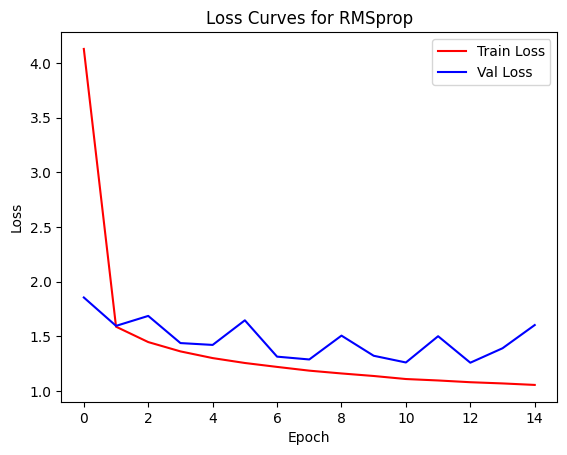

In [7]:
from torch.optim import Adam, SGD, RMSprop

configs = [ {'name': 'adam_lr0.01_beta0.85','optimizer': lambda: Adam(model.parameters(), lr=0.01, betas=(0.85, 0.99))},
            {'name': 'adam_lr0.0001','optimizer': lambda: Adam(model.parameters(), lr=0.0001)},
            {'name': 'SGD_lr0.01', 'optimizer': lambda: SGD(model.parameters(), lr=0.01, momentum=0.9)},
            {'name': 'SGD_lr0.1', 'optimizer': lambda: SGD(model.parameters(), lr=0.1, momentum=0.9)},
            {'name': 'RMSprop', 'optimizer': lambda: RMSprop(model.parameters())}
          ]

### TODO: dokoncit config setup

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

batch_size = 32

dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying optimizer: {config['name']}")

    model, model_inference = build_model_task3()
    model.to(device)
    model_inference.to(device)

    optimizer = config['optimizer']()
    print(optimizer.state_dict()['param_groups'])

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(15):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        print(f"Val loss at epoch {e}: {val_loss}")
        print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [8]:
import json

# Combine the losses and accuracies into a single dictionary
results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

# Specify the filename
output_filename = 'optimizers_results.json'

# Dump the dictionary to a JSON file
with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to optimizers_results.json


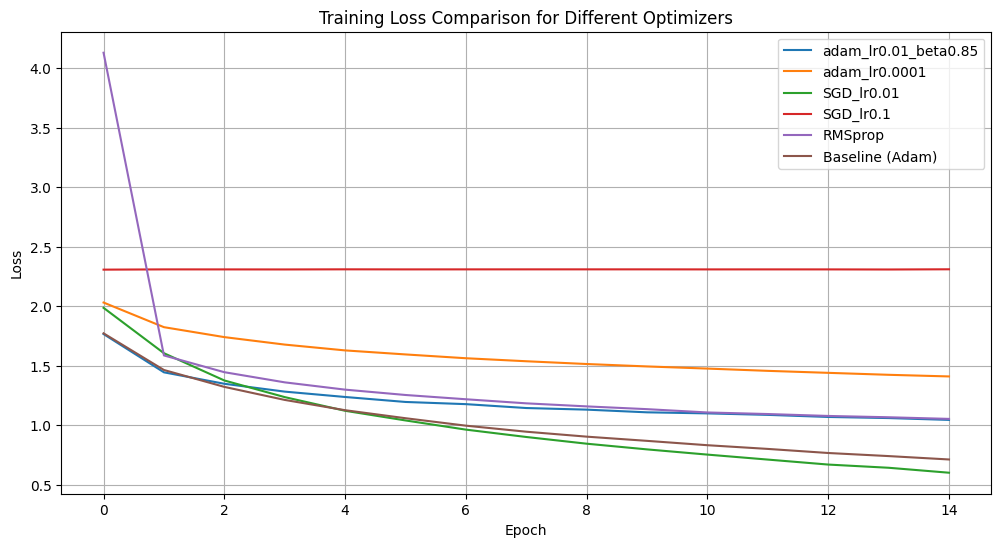

In [9]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][0][0], label=optimizer_name['name'])

plt.plot(baseline_train_losses, label='Baseline (Adam)')

plt.title('Training Loss Comparison for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

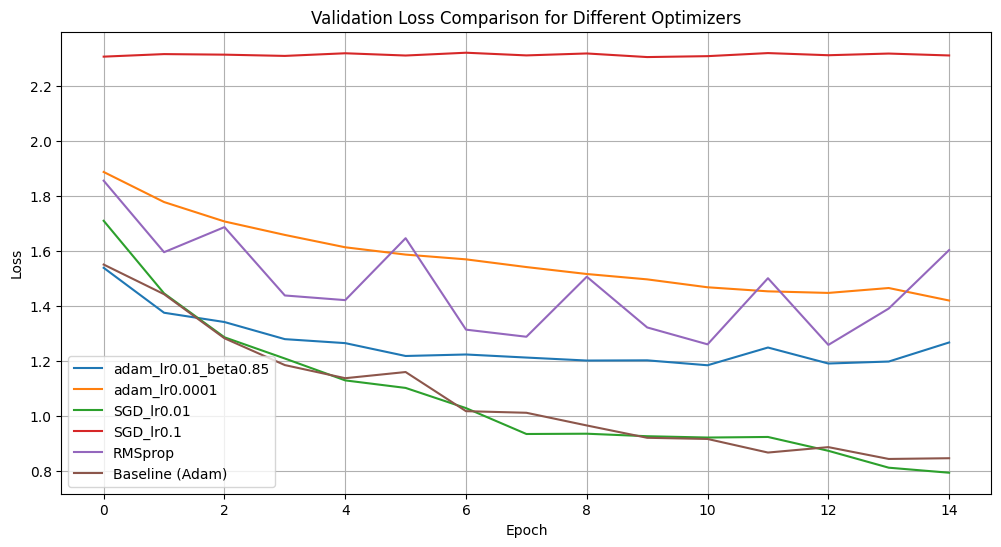

In [10]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][1][0], label=optimizer_name['name'])

# Assuming you have the baseline model's val_losses stored in baseline_val_losses
plt.plot(baseline_val_losses, label='Baseline (Adam)')

plt.title('Validation Loss Comparison for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

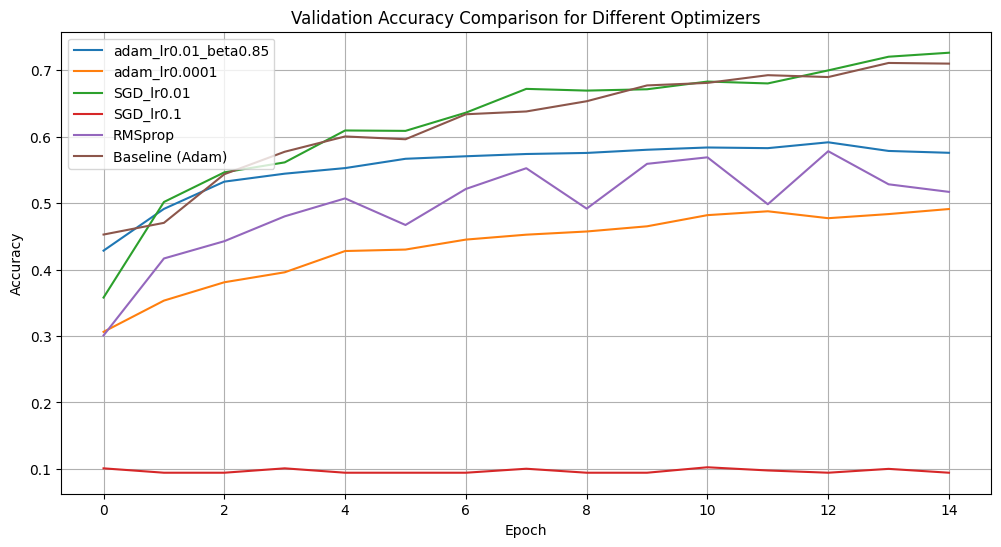

In [11]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(accuracies[optimizer_name['name']][0], label=optimizer_name['name'])

# Assuming you have the baseline model's val_accs stored in baseline_val_accs
plt.plot(baseline_val_accs, label='Baseline (Adam)')

plt.title('Validation Accuracy Comparison for Different Optimizers')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
import pandas as pd

summary_data = {}

# Get baseline results
summary_data['Baseline (Adam)'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

# Get results for each optimizer
for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
Baseline (Adam),0.712818,0.845021,0.7098
adam_lr0.01_beta0.85,1.045242,1.266049,0.5756
adam_lr0.0001,1.410405,1.418583,0.4910
SGD_lr0.01,0.601520,0.792280,0.7262
SGD_lr0.1,2.310532,2.309857,0.0942
RMSprop,1.053760,1.602071,0.5168


Using device:  cuda:0
Trying batch size: batch_size_64
Val loss at epoch 0: 1.6690846017644376
Val acc at epoch 0: 0.3996
Val loss at epoch 1: 1.4768553519550758
Val acc at epoch 1: 0.48
Val loss at epoch 2: 1.4250105966495563
Val acc at epoch 2: 0.4896
Val loss at epoch 3: 1.2525472105303896
Val acc at epoch 3: 0.554
Val loss at epoch 4: 1.1895082675957982
Val acc at epoch 4: 0.573
Val loss at epoch 5: 1.150333150278164
Val acc at epoch 5: 0.5956
Val loss at epoch 6: 1.1274471335773226
Val acc at epoch 6: 0.6088
Val loss at epoch 7: 1.0407365930231312
Val acc at epoch 7: 0.6344
Val loss at epoch 8: 1.062337400038031
Val acc at epoch 8: 0.6258
Val loss at epoch 9: 1.0435886775391012
Val acc at epoch 9: 0.6286
Val loss at epoch 10: 0.9799979434737677
Val acc at epoch 10: 0.656
Val loss at epoch 11: 1.036976335169394
Val acc at epoch 11: 0.6322
Val loss at epoch 12: 0.9417083399205268
Val acc at epoch 12: 0.674
Val loss at epoch 13: 0.9047459152680409
Val acc at epoch 13: 0.6848
Val loss

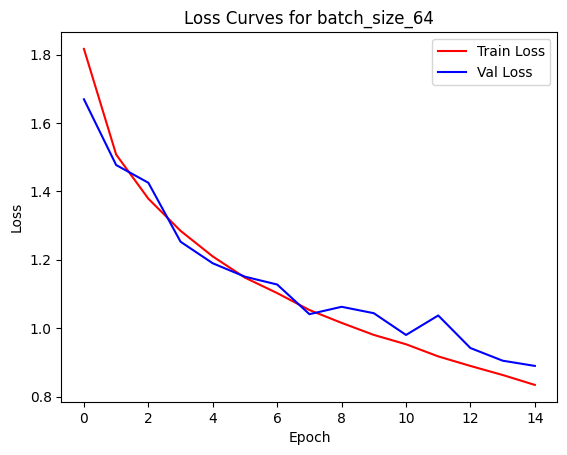

Trying batch size: batch_size_128
Val loss at epoch 0: 1.7192472606897353
Val acc at epoch 0: 0.3888
Val loss at epoch 1: 1.5273148179054261
Val acc at epoch 1: 0.4528
Val loss at epoch 2: 1.4607375115156174
Val acc at epoch 2: 0.484
Val loss at epoch 3: 1.3788849055767058
Val acc at epoch 3: 0.503
Val loss at epoch 4: 1.3242124885320663
Val acc at epoch 4: 0.527
Val loss at epoch 5: 1.281810748577118
Val acc at epoch 5: 0.5392
Val loss at epoch 6: 1.242475411295891
Val acc at epoch 6: 0.5596
Val loss at epoch 7: 1.180507081747055
Val acc at epoch 7: 0.5822
Val loss at epoch 8: 1.1475967735052108
Val acc at epoch 8: 0.588
Val loss at epoch 9: 1.1235215440392494
Val acc at epoch 9: 0.6018
Val loss at epoch 10: 1.1339596599340438
Val acc at epoch 10: 0.5964
Val loss at epoch 11: 1.0921419754624366
Val acc at epoch 11: 0.6074
Val loss at epoch 12: 1.0983207136392594
Val acc at epoch 12: 0.6126
Val loss at epoch 13: 1.0650132656097413
Val acc at epoch 13: 0.6172
Val loss at epoch 14: 0.996

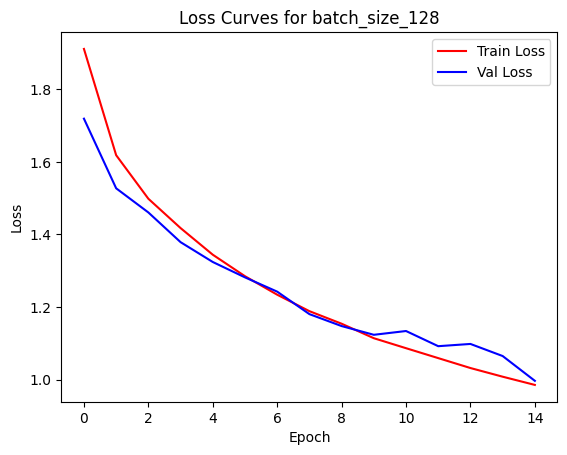

Trying batch size: batch_size_16
Val loss at epoch 0: 1.4436390946467463
Val acc at epoch 0: 0.4736
Val loss at epoch 1: 1.236954752248697
Val acc at epoch 1: 0.5686
Val loss at epoch 2: 1.0913041475862741
Val acc at epoch 2: 0.6144
Val loss at epoch 3: 1.0282200009297258
Val acc at epoch 3: 0.638
Val loss at epoch 4: 0.9534275678400034
Val acc at epoch 4: 0.665
Val loss at epoch 5: 0.998384840381793
Val acc at epoch 5: 0.6448
Val loss at epoch 6: 0.8599948580272663
Val acc at epoch 6: 0.6988
Val loss at epoch 7: 0.8464142435941452
Val acc at epoch 7: 0.7
Val loss at epoch 8: 0.8365536503041514
Val acc at epoch 8: 0.7054
Val loss at epoch 9: 0.8759840320283994
Val acc at epoch 9: 0.6966
Val loss at epoch 10: 0.825962741820576
Val acc at epoch 10: 0.7188
Val loss at epoch 11: 0.8247169405698015
Val acc at epoch 11: 0.7216
Val loss at epoch 12: 0.798662123612512
Val acc at epoch 12: 0.7258
Val loss at epoch 13: 0.8059916164452275
Val acc at epoch 13: 0.7208
Val loss at epoch 14: 0.830405

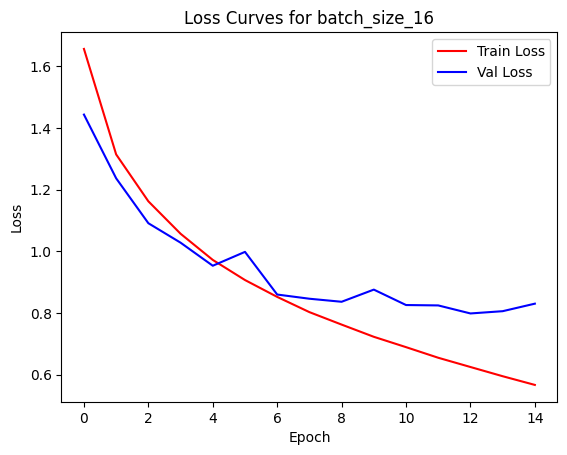

In [13]:
# TODO: Experiments with batch size
from torch.optim import Adam

configs = [ {'name': 'batch_size_64','size': 64},
            {'name': 'batch_size_128','size': 128},
            {'name': 'batch_size_16', 'size': 16}
          ]

### TODO: dokoncit config setup

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying batch size: {config['name']}")

    # Re-initialize model and optimizer for each batch size experiment
    model, model_inference = build_model_task3()
    model.to(device)
    model_inference.to(device)
    optimizer = Adam(model.parameters())


    batch_size = config['size']
    dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
    dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(15):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        print(f"Val loss at epoch {e}: {val_loss}")
        print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [14]:
import json

# Combine the losses and accuracies into a single dictionary
results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

# Specify the filename
output_filename = 'optimizers_batchsize_results.json'

# Dump the dictionary to a JSON file
with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to optimizers_batchsize_results.json


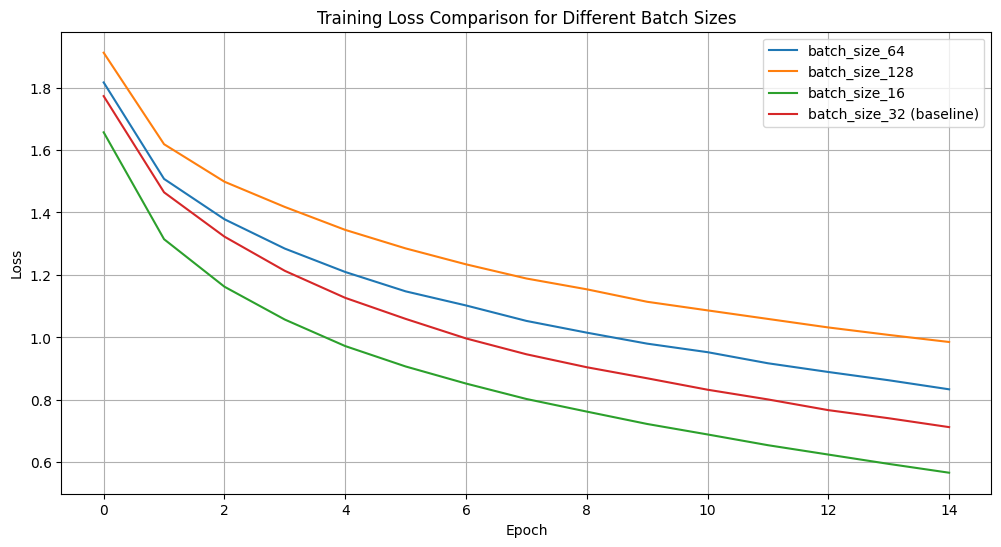

In [15]:
plt.figure(figsize=(12, 6))
for config in configs:
    plt.plot(losses[config['name']][0][0], label=config['name'])

plt.plot(baseline_train_losses, label='batch_size_32 (baseline)')

plt.title('Training Loss Comparison for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

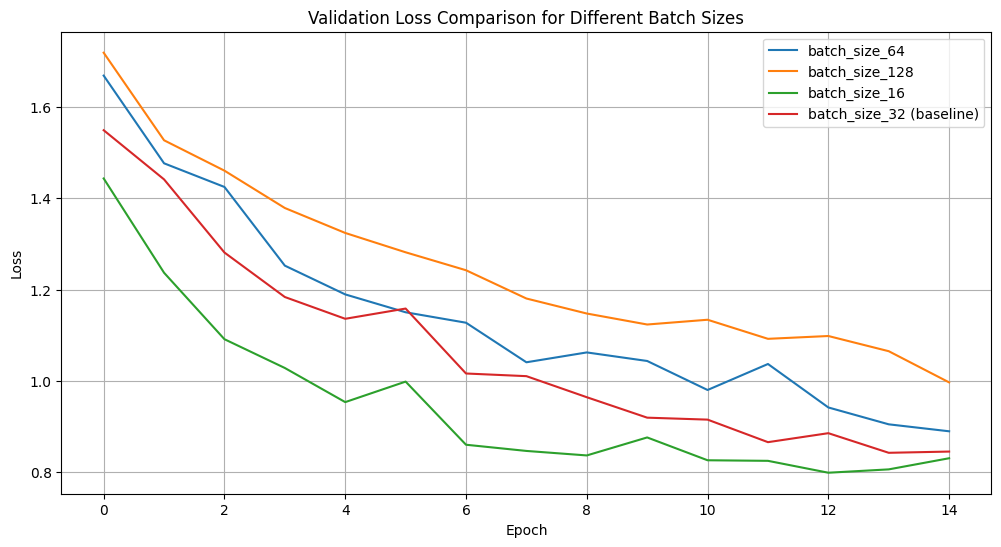

In [16]:
plt.figure(figsize=(12, 6))
for config in configs:
    plt.plot(losses[config['name']][1][0], label=config['name'])

# Assuming you have the baseline model's val_losses stored in baseline_val_losses
plt.plot(baseline_val_losses, label='batch_size_32 (baseline)')

plt.title('Validation Loss Comparison for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

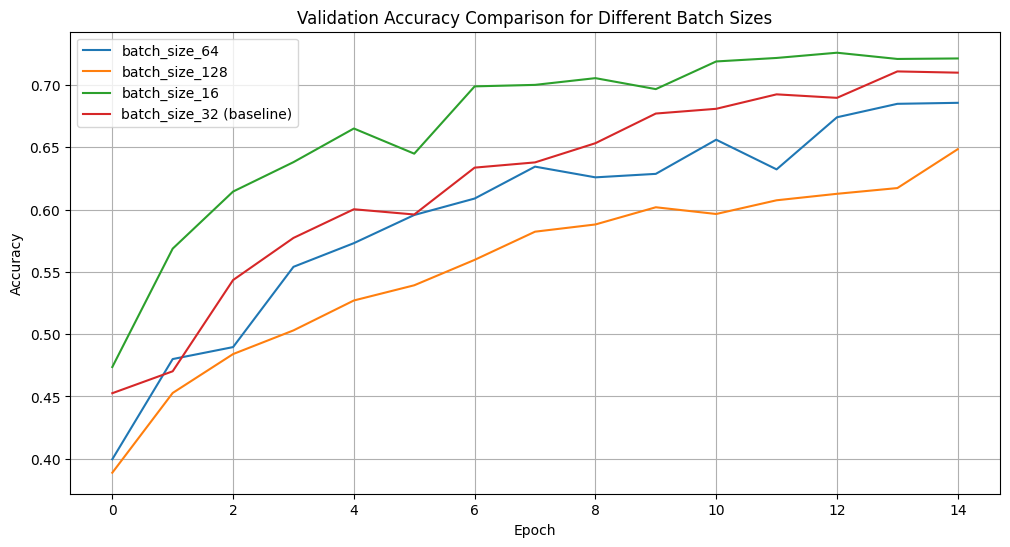

In [17]:
plt.figure(figsize=(12, 6))
for config in configs:
    plt.plot(accuracies[config['name']][0], label=config['name'])

# Assuming you have the baseline model's val_accs stored in baseline_val_accs
plt.plot(baseline_val_accs, label='batch_size_32 (baseline)')

plt.title('Validation Accuracy Comparison for Different Batch Sizes')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
import pandas as pd

summary_data = {}

# Get baseline results
summary_data['batch_size_32 (baseline)'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

# Get results for each optimizer
for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
batch_size_32 (baseline),0.712818,0.845021,0.7098
batch_size_64,0.833895,0.889472,0.6856
batch_size_128,0.985370,0.996659,0.6484
batch_size_16,0.566856,0.830405,0.7212
